In [ ]:
import itertools
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib import colors as mcolors
from pypalettes import load_cmap
from rich.progress import track

from rojak.atmosphere.regions import (
    combine_two_features,
)
from rojak.core.calculations import interpolation_on_lat_lon
from rojak.core.constants import TWENTIES_CLIMATOLOGICAL_PARAMETER
from rojak.core.data import load_from_folder
from rojak.core.geometric import geodesic_waypoints_between
from rojak.datalib.ecmwf.era5 import Era5Data
from rojak.orchestrator.configuration import (
    SpatialDomain,
    TurbulenceDiagnostics,
)
from rojak.orchestrator.lite_controller import (
    load_distribution_parameters_from_file,
)
from rojak.plot.regions_plotter import (
    create_regions_snapshot_plot,
)
from rojak.plot.utilities import _PLATE_CARREE, StandardColourMaps, get_a_default_cmap
from rojak.turbulence.analysis import (
    TransformToEDR,
)
from rojak.turbulence.diagnostic import DiagnosticFactory
from rojak.utilities.types import Coordinate

## Set up

### Load meteorological data for turbulence diagnostics


In [ ]:
folder_path = Path("/path/to/era5_data/end_2025")
spatial_domain = SpatialDomain(
    minimum_latitude=-75,
    maximum_latitude=75,
    minimum_longitude=-180,
    maximum_longitude=180,
    grid_size=0.25,
)
data = Era5Data(
    load_from_folder(
        folder_path,
        chunks={"pressure_level": 6, "latitude": 721, "longitude": 1440},
        engine="h5netcdf",
    )
).to_clear_air_turbulence_data(spatial_domain)
data._dataset = data._dataset.sel(time="2025-12-29T18")
dist_params_file = Path("/path/to/distribution_params.json")
distribution_parameters = load_distribution_parameters_from_file(dist_params_file)

### Compute turbulence diagnostics

In [ ]:
target_diagnostics = [
    TurbulenceDiagnostics.TI1,
    TurbulenceDiagnostics.NCSU1,
    TurbulenceDiagnostics.BROWN2,
]
diagnostic_factory = DiagnosticFactory(data)
diagnostics: xr.Dataset = xr.Dataset(
    data_vars={
        str(diagnostic): TransformToEDR(
            diagnostic_factory.create(diagnostic).computed_value,
            c1=TWENTIES_CLIMATOLOGICAL_PARAMETER.c1,
            c2=TWENTIES_CLIMATOLOGICAL_PARAMETER.c2,
            mean=distribution_parameters[str(diagnostic)].mean,
            variance=distribution_parameters[str(diagnostic)].variance,
        ).execute()
        for diagnostic in track(target_diagnostics, "Computing turbulence diagnostics")
    },
    coords=data.u_wind().coords,
)

In [4]:
def has_turb_waypoints(
    waypoints: xr.DataArray, target_diagnostic: xr.DataArray, minimum_edr: float = 0.22
) -> xr.DataArray:
    return (
        interpolation_on_lat_lon(target_diagnostic, waypoints, points_dim="waypoints")
        > minimum_edr
    )

### Compute great circle route between JFK and LHR

In [5]:
lhr = Coordinate(51.47138888, -0.45277777)
jfk = Coordinate(40.641766, -73.780968)

points = geodesic_waypoints_between(lhr, jfk, 0.25)
waypoints = xr.DataArray(points, dims=["waypoints", "xy"])

In [6]:
mid_point_idx: int = len(points) // 2

In [ ]:
interp_contrails = data.issr_along_path(points[:, 0], points[:, 1]).transpose(
    "pressure_level", "waypoints"
)

In [ ]:
interp_turb_issr = {
    name: combine_two_features(
        interp_contrails, has_turb_waypoints(waypoints, target_array), is_guv=False
    ).persist()
    for name, target_array in diagnostics.data_vars.items()
}

In [9]:
titles = {
    TurbulenceDiagnostics.TI1: "Turbulence Index 1",
    TurbulenceDiagnostics.NCSU1: "NCSU1",
    TurbulenceDiagnostics.BROWN2: "Brown2",
}

In [10]:
def get_panel_letter(panel_index: int, is_lower: bool = True) -> str:
    start_char = "`" if is_lower else "@"
    return chr(ord(start_char) + panel_index + 1)

## Create vertical cross-section plots

### Plotting utility function

This is not in the upstream version of `rojak` so it has been copied in here

In [ ]:
def combined_regions_cbar_norm(
    cmap: mcolors.Colormap,
) -> tuple[mcolors.BoundaryNorm, list[float]]:
    boundaries: list[int] = [0, 0b001, 0b100, 0b111, 8]
    new_cbar_tick_locations = [
        (first + second) / 2 for first, second in itertools.pairwise(boundaries[1:])
    ]
    return mcolors.BoundaryNorm(boundaries, cmap.N), new_cbar_tick_locations


def create_interpolated_combined_regions_plot(
    da_to_plot: xr.DataArray,
    first_feature_name: str,
    second_feature_name: str,
    plot_name: str,
    return_facet_grid: bool = False,
    plot_kwargs: dict | None = None,
) -> xr.plot.FacetGrid:  # pyright: ignore[reportAttributeAccessIssue]
    cmap = get_a_default_cmap(StandardColourMaps.FEATURE_REGIONS)
    cbar_norm, new_cbar_tick_locations = combined_regions_cbar_norm(cmap)
    default_plot_kwargs = {
        "cmap": cmap,
        "norm": cbar_norm,
        **(plot_kwargs if plot_kwargs is not None else {}),
    }
    fg: xr.plot.FacetGrid = da_to_plot.plot(**default_plot_kwargs)  # pyright: ignore[reportAttributeAccessIssue]

    if return_facet_grid:
        return fg

    fg.fig.savefig(plot_name, dpi=400, bbox_inches="tight")
    plt.close(fg.fig)
    return None

### Generate plots

In [ ]:
PLOTS_BASE_PATH = "path/to/plots/"

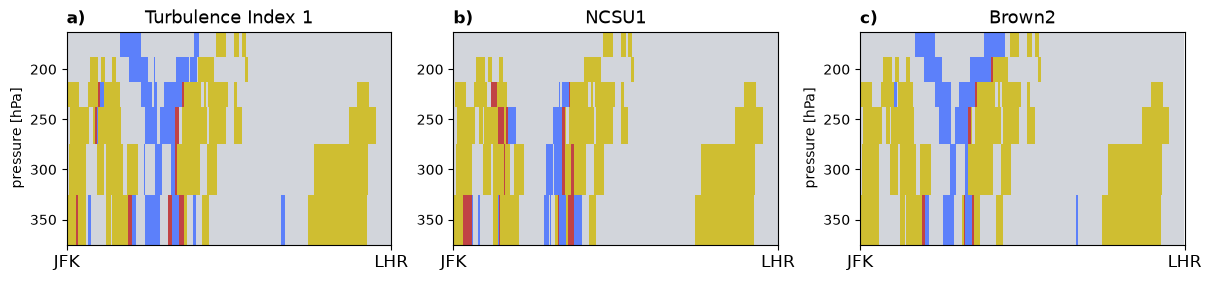

In [ ]:
for time_index in range(1):
    fig, axs = plt.subplots(1, 3, figsize=(12, 2.7), layout="constrained")
    for axs_index, (name, target_array) in enumerate(interp_turb_issr.items()):
        this_ax = axs[axs_index]
        create_interpolated_combined_regions_plot(
            target_array,
            "ISSR",
            "MOG CAT",
            "",
            return_facet_grid=True,
            plot_kwargs={
                "yincrease": False,
                "xincrease": False,
                "rasterized": True,
                "add_colorbar": False,
                "ax": this_ax,
            },
        )
        this_ax.set_xticks([-1, len(points)])
        this_ax.set_xticklabels(["LHR", "JFK"], fontsize=12)
        this_ax.set_title(f"{titles[name]}", fontsize=13)
        this_ax.set_title(
            f"{get_panel_letter(axs_index)})", loc="left", fontweight="bold"
        )
        this_ax.set_xlabel("")
    axs[1].set_ylabel("")
    fig.savefig(
        f"{PLOTS_BASE_PATH}/labelled_interpolated_2025-12-29T18.png",
        dpi=200,
        transparent=True,
    )

## Horizontal cross section plots

### Compute horizontal cross section for CAT and ISSR field

In [ ]:
longitudinal = {
    name: combine_two_features(
        data.ice_supersaturated_regions(rhi_threshold=1.0),
        target_array > 0.22,
        is_guv=False,
    ).persist()
    for name, target_array in diagnostics.data_vars.items()
}

In [15]:
mid_point = lhr.mid_point_from(jfk)

### Load mean sea level pressure data

In [16]:
def shift_longitude(
    data: xr.Dataset,
    domain_bound: float = -180,
    sort_data: bool = True,
    longitude_coord_name: str = "longitude",
) -> xr.Dataset:
    # Utility function to shift data to have longitude in the range of [domain_bound, 360 + domain_bound]
    # This also sorts it so that the data is then ascending from domain_bound
    shifted_data: xr.Dataset = data.assign_coords(
        longitude=((data[longitude_coord_name] - domain_bound) % 360) + domain_bound,
    )
    return (
        shifted_data.sortby(longitude_coord_name, ascending=True)
        if sort_data
        else shifted_data
    )

In [ ]:
surface_pressure_path = Path("/path/to/era5/data/surface-pressure/end_2025")
TARGET_FILE: str = "*.nc"
msl_ds: xr.Dataset = xr.open_mfdataset(
    str(surface_pressure_path / TARGET_FILE),
    chunks={"pressure_level": 6, "latitude": 721, "longitude": 1440},
    parallel=True,
    engine="h5netcdf",
    decode_coords=True,
    decode_cf=True,
    decode_timedelta=True,
).rename({"valid_time": "time"})
msl: xr.DataArray = shift_longitude(msl_ds).msl.persist()
msl = msl.sel(time="2025-12-29T18")

### Create horizontal cross-section plots

In [18]:
levels = np.arange(970, 1050, 10)
bar_color = load_cmap("Casita1").colors[-1]

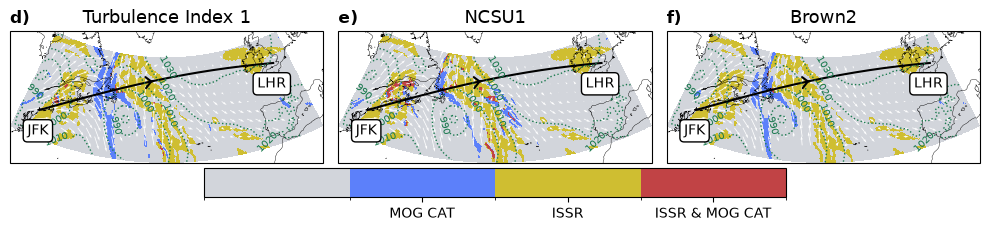

In [ ]:
longitudinal_ds = xr.Dataset(data_vars=longitudinal)
for time_index in range(1):
    fg = create_regions_snapshot_plot(
        longitudinal_ds.sel(
            pressure_level=250, latitude=slice(57, 35), longitude=slice(-79, 5)
        ).to_dataarray(dim="diagnostic"),
        "ISSR",
        "MOG CAT",
        "test",
        col_coord="diagnostic",
        return_facet_grid=True,
        plot_kwargs={
            "subplot_kws": {
                "projection": ccrs.LambertConformal(
                    central_longitude=mid_point.longitude,
                    central_latitude=mid_point.latitude,
                )
            },
            "rasterized": True,
            "cbar_kwargs": {
                "orientation": "horizontal",
                "spacing": "uniform",
                "pad": 0.02,
                "shrink": 0.6,
            },
        },
    )
    data_subset = (
        data._dataset.sel(
            pressure_level=250, latitude=slice(57, 35), longitude=slice(-79, 5)
        )
        .coarsen(latitude=10, longitude=10, boundary="trim")
        .mean()
    )

    for ax_index, ax in enumerate(fg.axs.flat):
        ax.plot(points[:, 0], points[:, 1], color="k", transform=_PLATE_CARREE)
        contour_for_ax = (
            msl.sel(latitude=slice(57, 35), longitude=slice(-79, 5)) / 100
        ).plot.contour(
            transform=_PLATE_CARREE,
            levels=levels,
            colors=bar_color,
            linewidths=1,
            linestyles="dotted",
            ax=ax,
        )
        contour_for_ax.clabel(inline=True, fontsize=7)
        ax.set_title(
            f"{get_panel_letter(ax_index + 3)})", loc="left", fontweight="bold"
        )
        ax.quiver(
            x=data_subset["longitude"].to_numpy(),
            y=data_subset["latitude"].to_numpy(),
            u=data_subset["eastward_wind"].to_numpy(),
            v=data_subset["northward_wind"].to_numpy(),
            transform=_PLATE_CARREE,
            color="white",
            regrid_shape=16,
        )
        ax.annotate(
            "",
            xy=(points[mid_point_idx, 0], points[mid_point_idx, 1]),
            xytext=(points[mid_point_idx + 5, 0], points[mid_point_idx + 5, 1]),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5, mutation_aspect=2),
            transform=_PLATE_CARREE,
        )
        ax.annotate(
            "LHR",
            xy=(points[0, 0], points[0, 1]),
            c="k",
            xytext=(-0.1, -1.5),
            textcoords="offset fontsize",
            va="center",
            ha="center",
            bbox=dict(boxstyle="round", fc="w"),
            transform=_PLATE_CARREE,
        )
        ax.annotate(
            "JFK",
            xy=(points[-1, 0], points[-1, 1]),
            c="k",
            xytext=(-0.1, -1.5),
            textcoords="offset fontsize",
            va="center",
            ha="center",
            bbox=dict(boxstyle="round", fc="w"),
            transform=_PLATE_CARREE,
            zorder=10,
        )
        ax.set_title(list(titles.values())[ax_index], fontsize=13)
    fg.fig.savefig(
        f"{PLOTS_BASE_PATH}/jfk_wind_lat_lon_2026-12-29T18.png",
        dpi=400,
        bbox_inches="tight",
        transparent=True,
    )